# 2주차 업무 진행 가이드

## 주제: Unit Test 구성 및 2D → 3D 변환 실습

이 노트북은 2주차 업무를 **어떤 순서로 진행해야 하는지**와 **각 단계가 왜 필요한지**를 함께 정리한 실행형 가이드이다.

Week 2의 목표는 **테스트 케이스를 완성하고, 최종 Unit Test 실행 결과와 Depth Map / 3D 변환 결과물을 제출 가능한 형태로 정리하는 것**이다.

## 0. 전체 순서와 의미

2주차 업무 요청서의 큰 흐름은 다음과 같다.

1. **Unit Test 작성 및 코드 검증**
2. **2D 이미지를 3D로 변환하는 알고리즘 구현**
3. **코드 검증 및 결과 분석**

실제로 작업할 때는 아래 순서로 진행하는 것이 자연스럽다.

| 순서 | 해야 할 일 | 의미 | 산출물 |
|---:|---|---|---|
| 1 | `week2` 브랜치 확인 | 2주차 작업을 기존 코드와 분리 | Git 브랜치 |
| 2 | 환경 설정 | 코드 실행과 테스트에 필요한 도구 준비 | `numpy`, `opencv-python`, `pytest`, `matplotlib` |
| 3 | 폴더 구조 정리 | 코드, 테스트, 결과물을 분리 | `src/`, `tests/`, `outputs/` |
| 4 | 2D → Depth Map 함수 정리 | 테스트할 핵심 기능 구현 | `generate_depth_map()` |
| 5 | 3D Point Cloud 함수 추가 | 2D 좌표와 Depth 값을 3D 좌표처럼 표현 | `create_point_cloud()` |
| 6 | Unit Test 케이스 작성 | 함수가 정상 동작하는지 자동 검증 | `tests/test_day2_depth_processing.py` |
| 7 | Unit Test 재실행 | 제출 가능한 검증 결과 확보 | `outputs/pytest_result.txt` |
| 8 | 결과 이미지 저장 | PPT/README에 넣을 시각 자료 생성 | `depth_map.png`, `point_cloud_preview.png` |
| 9 | 결과 분석 작성 | 구현 내용, 테스트 결과, 한계점, 개선점을 설명 | README/PPT 내용 |
| 10 | GitHub 업로드 | 제출 링크 준비 | GitHub 링크 또는 PR 링크 |

> 핵심: **Unit Test 실행은 마지막에 한 번만 하는 작업이 아니라, 테스트 케이스를 작성하면서 계속 반복하는 검증 작업**이다. 다만 제출용으로는 테스트 케이스를 보완한 뒤 최종 실행 결과를 남기는 것이 좋다.

## 1. Git 브랜치 확인

이미 `week2` 브랜치를 만들었다면 아래 명령어로 현재 브랜치를 확인한다.

```bash
git branch --show-current
```

`week2`가 아니라면 아래처럼 이동한다.

```bash
git checkout week2
```

아직 브랜치를 만들지 않았다면 아래 명령어를 사용한다.

```bash
git checkout -b week2
```

### 이 단계의 의미

브랜치를 나누는 이유는 2주차 작업 내용을 따로 관리하기 위해서이다. 실무에서는 기능 단위로 브랜치를 나누고, 작업이 끝나면 Pull Request를 통해 리뷰 후 병합한다.

## 2. 라이브러리 설치

이번 과제에 필요한 최소 라이브러리는 아래와 같다.

- `numpy`: 이미지와 포인트 클라우드를 배열로 처리한다.
- `opencv-python`: 이미지 로드, Grayscale 변환, Depth Map 생성을 수행한다.
- `pytest`: Unit Test를 실행한다.
- `matplotlib`: 노트북에서 결과 이미지를 확인한다.

In [1]:
%pip install numpy opencv-python pytest matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 3. 프로젝트 폴더 구조 만들기

아래처럼 정리하면 제출할 때 깔끔하다.

```text
.
├── sample.jpg
├── src/
│   ├── __init__.py
│   └── day2_depth_processing.py
├── tests/
│   └── test_day2_depth_processing.py
├── outputs/
│   ├── grayscale.png
│   ├── depth_map.png
│   ├── point_cloud.npy
│   ├── point_cloud_preview.png
│   └── pytest_result.txt
├── README.md
├── ppt_outline.md
├── requirements.txt
└── .gitignore
```

### 이 단계의 의미

- `src/`: 실제 기능 코드가 들어가는 폴더
- `tests/`: Unit Test 코드가 들어가는 폴더
- `outputs/`: 실행 결과 이미지와 테스트 결과가 들어가는 폴더
- `README.md`: 과제 설명 문서
- `ppt_outline.md`: PPT에 넣을 내용 초안
- `requirements.txt`: 실행에 필요한 라이브러리 목록
- `.gitignore`: GitHub에 올리지 않을 파일을 지정하는 파일

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
TEST_DIR = PROJECT_ROOT / "tests"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for directory in [SRC_DIR, TEST_DIR, OUTPUT_DIR]:
    directory.mkdir(exist_ok=True)

(SRC_DIR / "__init__.py").touch()

print("프로젝트 루트:", PROJECT_ROOT)
print("생성 또는 확인한 폴더:")
for directory in [SRC_DIR, TEST_DIR, OUTPUT_DIR]:
    print("-", directory.relative_to(PROJECT_ROOT))

프로젝트 루트: c:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week2
생성 또는 확인한 폴더:
- src
- tests
- outputs


## 4. 테스트용 이미지 준비

과제에는 분석할 2D 이미지가 필요하다. 사용할 이미지를 `sample.jpg`라는 이름으로 현재 폴더에 넣었다.

### 이 단계의 의미

Depth Map과 Point Cloud는 입력 이미지가 있어야 만들 수 있다. 테스트 코드에서는 가짜 배열을 사용해도 되지만, 결과물 이미지와 PPT에는 실제 입력 이미지가 필요하다.

따라서 sample.jpg 파일로 작업을 진행한다.

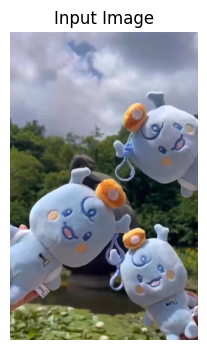

이미지 shape: (688, 418, 3)


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = PROJECT_ROOT / "sample.jpg"

image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise ValueError("sample.jpg를 읽을 수 없다. 파일 경로와 확장자를 확인해야 한다.")

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis("off")
plt.show()

print("이미지 shape:", image.shape)

## 5. 핵심 기능 코드 작성

이제 실제 기능 코드를 `src/day2_depth_processing.py`에 작성한다.

이번 코드에서 구현할 함수는 다음과 같다.

| 함수 | 역할 |
|---|---|
| `load_image()` | 이미지 파일을 안전하게 로드한다. |
| `to_grayscale()` | BGR 이미지를 Grayscale로 변환한다. |
| `generate_depth_map()` | Grayscale 밝기 값을 기반으로 가상의 Depth Map을 생성한다. |
| `create_point_cloud()` | `(x, y, z)` 형태의 3D 포인트 배열을 생성한다. |
| `save_outputs()` | Grayscale, Depth Map, Point Cloud 결과를 저장한다. |

### 이 단계의 의미

Unit Test는 테스트할 대상 함수가 있어야 작성할 수 있다. 그래서 먼저 기능 코드를 함수 단위로 분리한다. 함수 단위로 분리하면 테스트하기 쉽고, README/PPT에도 구조를 설명하기 좋다.

> 주의: 여기서 만드는 Depth Map은 단일 이미지의 밝기 값을 이용한 **가상의 깊이 표현**이다. 실제 거리 정보를 의미하지는 않는다.

In [5]:
%%writefile src/depth_processing.py
from pathlib import Path

import cv2
import numpy as np


def load_image(image_path):
    """이미지 파일을 OpenCV BGR 형식으로 로드한다."""
    path = Path(image_path)

    if not path.exists():
        raise FileNotFoundError(f"이미지 파일을 찾을 수 없다: {path}")

    image = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError(f"이미지를 읽을 수 없다. 파일 형식을 확인해야 한다: {path}")

    return image


def _validate_image_array(image):
    """입력 이미지 배열이 처리 가능한 형태인지 확인한다."""
    if image is None:
        raise ValueError("입력 이미지가 None이다.")

    if not isinstance(image, np.ndarray):
        raise TypeError("입력 이미지는 numpy.ndarray 타입이어야 한다.")

    if image.ndim not in (2, 3):
        raise ValueError("입력 이미지는 2D Grayscale 또는 3D BGR 이미지여야 한다.")

    if image.ndim == 3 and image.shape[2] != 3:
        raise ValueError("3D 이미지는 BGR 3채널이어야 한다.")

    return image


def to_grayscale(image):
    """BGR 이미지 또는 Grayscale 이미지를 Grayscale 2D 배열로 변환한다."""
    image = _validate_image_array(image)

    if image.ndim == 2:
        return image.copy()

    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def generate_depth_map(image, colormap=cv2.COLORMAP_JET):
    """Grayscale 밝기 값을 기반으로 가상의 Depth Map 이미지를 생성한다."""
    gray = to_grayscale(image)

    # 입력 이미지의 밝기 범위를 0~255로 정규화한다.
    normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    normalized = normalized.astype(np.uint8)

    # 밝기 값에 색상 맵을 적용하여 Depth Map처럼 시각화한다.
    depth_map = cv2.applyColorMap(normalized, colormap)

    return depth_map


def create_point_cloud(image, stride=4):
    """이미지의 x, y 좌표와 밝기 값을 z로 사용하여 간단한 3D 포인트 배열을 생성한다.

    Args:
        image: BGR 또는 Grayscale 이미지 배열
        stride: 모든 픽셀을 쓰면 포인트가 너무 많으므로 샘플링 간격을 지정한다.

    Returns:
        shape이 (N, 3)인 numpy.ndarray이다. 각 행은 [x, y, z]를 의미한다.
    """
    if not isinstance(stride, int) or stride < 1:
        raise ValueError("stride는 1 이상의 정수여야 한다.")

    gray = to_grayscale(image).astype(np.float32)
    sampled_gray = gray[::stride, ::stride]

    height, width = sampled_gray.shape
    y_grid, x_grid = np.mgrid[0:height, 0:width]

    x = (x_grid * stride).astype(np.float32)
    y = (y_grid * stride).astype(np.float32)
    z = sampled_gray

    points_3d = np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)

    return points_3d


def save_outputs(image_path, output_dir, stride=4):
    """입력 이미지로부터 Grayscale, Depth Map, Point Cloud 결과물을 저장한다."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    image = load_image(image_path)
    gray = to_grayscale(image)
    depth_map = generate_depth_map(image)
    points_3d = create_point_cloud(image, stride=stride)

    grayscale_path = output_dir / "grayscale.png"
    depth_map_path = output_dir / "depth_map.png"
    point_cloud_path = output_dir / "point_cloud.npy"

    cv2.imwrite(str(grayscale_path), gray)
    cv2.imwrite(str(depth_map_path), depth_map)
    np.save(str(point_cloud_path), points_3d)

    return {
        "grayscale_path": str(grayscale_path),
        "depth_map_path": str(depth_map_path),
        "point_cloud_path": str(point_cloud_path),
        "point_cloud_shape": points_3d.shape,
    }

Overwriting src/depth_processing.py


## 6. Unit Test 케이스 작성 및 보완

이제 테스트 코드를 `tests/test_day2_depth_processing.py`에 작성한다.

이번 테스트는 아래 내용을 확인한다.

1. Grayscale 변환 결과가 2D 배열인지 확인
2. Depth Map 결과가 원본 이미지와 같은 높이/너비를 가지는지 확인
3. Point Cloud 결과가 `(N, 3)` 형태인지 확인
4. 입력 이미지가 `None`일 때 예외 처리가 되는지 확인
5. 잘못된 `stride` 값이 들어왔을 때 예외 처리가 되는지 확인

### 이 단계의 의미

Unit Test는 “내 코드가 지금 정상적으로 동작한다”는 증거이다. 제출 자료에는 테스트 코드 자체와 실행 결과를 함께 남기는 것이 좋다.

In [6]:
%%writefile tests/test_depth_processing.py
import numpy as np
import pytest

from src.depth_processing import (
    to_grayscale,
    generate_depth_map,
    create_point_cloud,
)


def make_sample_image(height=80, width=100):
    """테스트용 BGR 샘플 이미지를 생성한다."""
    image = np.zeros((height, width, 3), dtype=np.uint8)
    image[:, :, 0] = 50
    image[:, :, 1] = 120
    image[:, :, 2] = 200
    return image


def test_to_grayscale_returns_2d_array():
    image = make_sample_image()

    gray = to_grayscale(image)

    assert isinstance(gray, np.ndarray)
    assert gray.ndim == 2
    assert gray.shape == image.shape[:2]


def test_generate_depth_map_keeps_image_size_and_has_three_channels():
    image = make_sample_image()

    depth_map = generate_depth_map(image)

    assert isinstance(depth_map, np.ndarray)
    assert depth_map.shape[:2] == image.shape[:2]
    assert depth_map.shape[2] == 3


def test_create_point_cloud_returns_xyz_points():
    image = make_sample_image(height=20, width=30)

    points = create_point_cloud(image, stride=5)

    assert isinstance(points, np.ndarray)
    assert points.ndim == 2
    assert points.shape[1] == 3
    assert len(points) > 0


def test_none_image_raises_value_error():
    with pytest.raises(ValueError):
        to_grayscale(None)


def test_invalid_stride_raises_value_error():
    image = make_sample_image()

    with pytest.raises(ValueError):
        create_point_cloud(image, stride=0)

Overwriting tests/test_depth_processing.py


## 7. Unit Test 재실행 및 결과 저장

이제 `pytest`를 실행한다.

실행 결과는 화면에 출력하고, 동시에 `outputs/pytest_result.txt`에 저장한다. 이 파일의 내용은 README와 PPT에 작성되었다.

### 이 단계의 의미

기본 테스트 실행을 이미 했더라도, 테스트 케이스를 보완한 뒤 다시 실행해야 최종 검증 결과로 사용할 수 있다.

In [7]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "tests"],
    capture_output=True,
    text=True,
)

pytest_text = result.stdout + "\n" + result.stderr
(OUTPUT_DIR / "pytest_result.txt").write_text(pytest_text, encoding="utf-8")

print(pytest_text)
print("pytest 결과 저장 위치:", OUTPUT_DIR / "pytest_result.txt")

if result.returncode != 0:
    raise RuntimeError("Unit Test가 실패했다. 위 에러 메시지를 보고 코드를 수정해야 한다.")

.....                                                                    [100%]
5 passed in 0.14s


pytest 결과 저장 위치: c:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week2\outputs\pytest_result.txt


## 8. 2D → Depth Map / 3D Point Cloud 결과 생성

테스트가 통과했다면 실제 이미지에 대해 결과물을 생성한다.

생성되는 파일은 다음과 같다.

```text
outputs/grayscale.png
outputs/depth_map.png
outputs/point_cloud.npy
```

### 이 단계의 의미

- `grayscale.png`: 원본 이미지를 밝기 정보 중심으로 변환한 결과
- `depth_map.png`: Grayscale 밝기 값을 색상으로 표현한 가상 Depth Map
- `point_cloud.npy`: 이미지 좌표 `(x, y)`와 밝기값 `z`를 결합한 3D 포인트 배열

In [8]:
from src.depth_processing import save_outputs

result_info = save_outputs(IMAGE_PATH, OUTPUT_DIR, stride=4)
result_info

{'grayscale_path': 'c:\\Users\\sooin\\Desktop\\Comento_CV\\proj\\Comento_CV_proj\\week2\\outputs\\grayscale.png',
 'depth_map_path': 'c:\\Users\\sooin\\Desktop\\Comento_CV\\proj\\Comento_CV_proj\\week2\\outputs\\depth_map.png',
 'point_cloud_path': 'c:\\Users\\sooin\\Desktop\\Comento_CV\\proj\\Comento_CV_proj\\week2\\outputs\\point_cloud.npy',
 'point_cloud_shape': (18060, 3)}

## 9. 결과 이미지 확인

원본 이미지, Grayscale 이미지, Depth Map 이미지를 비교한다.

PPT에는 보통 **원본 이미지**와 **Depth Map 이미지**를 넣으면 충분하다. 여유가 있으면 Point Cloud 미리보기까지 넣어도 좋다.

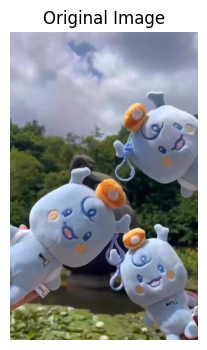

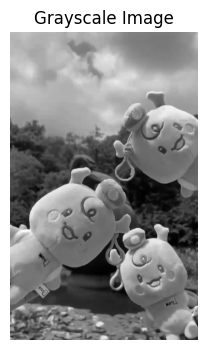

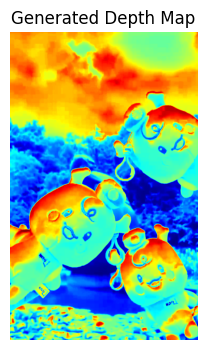

In [9]:
def show_bgr_image(path, title):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"이미지를 읽을 수 없다: {path}")

    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_gray_image(path, title):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"이미지를 읽을 수 없다: {path}")

    plt.figure(figsize=(6, 4))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

show_bgr_image(IMAGE_PATH, "Original Image")
show_gray_image(OUTPUT_DIR / "grayscale.png", "Grayscale Image")
show_bgr_image(OUTPUT_DIR / "depth_map.png", "Generated Depth Map")

## 10. Point Cloud 확인 및 미리보기 이미지 저장

Point Cloud는 이미지의 각 지점을 다음처럼 표현한 배열이다.

```text
[x좌표, y좌표, z값]
```

여기서 `z값`은 실제 거리값이 아니라, Grayscale 밝기 값을 깊이처럼 사용한 값이다.

### 이 단계의 의미

2D 이미지를 바로 진짜 3D 모델로 복원하는 것은 어렵기 때문에, **2D 픽셀 좌표 + 밝기 기반 Depth 값**을 이용해 3D 데이터 구조를 만들어보는 것이 핵심이다.

In [10]:
points = np.load(OUTPUT_DIR / "point_cloud.npy")

print("Point Cloud shape:", points.shape)
print("앞 10개 좌표:")
points[:10]

Point Cloud shape: (18060, 3)
앞 10개 좌표:


array([[  0.,   0., 190.],
       [  4.,   0., 189.],
       [  8.,   0., 190.],
       [ 12.,   0., 190.],
       [ 16.,   0., 190.],
       [ 20.,   0., 190.],
       [ 24.,   0., 193.],
       [ 28.,   0., 194.],
       [ 32.,   0., 194.],
       [ 36.,   0., 194.]], dtype=float32)

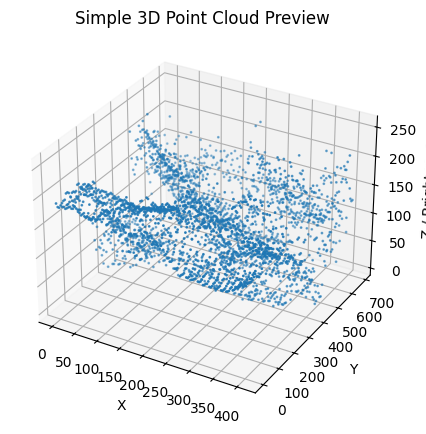

Point Cloud preview 저장 위치: c:\Users\sooin\Desktop\Comento_CV\proj\Comento_CV_proj\week2\outputs\point_cloud_preview.png


In [11]:
# Point Cloud 미리보기를 저장한다.
sample_size = min(3000, len(points))
step = max(1, len(points) // sample_size)
sampled_points = points[::step]

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sampled_points[:, 0], sampled_points[:, 1], sampled_points[:, 2], s=1)
ax.set_title("Simple 3D Point Cloud Preview")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z / Brightness")

preview_path = OUTPUT_DIR / "point_cloud_preview.png"
plt.savefig(preview_path, dpi=150, bbox_inches="tight")
plt.show()

print("Point Cloud preview 저장 위치:", preview_path)